<a href="https://colab.research.google.com/github/tassegaetan1/colab-git-assignment2-UT/blob/main/Lesson_7_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lesson 7 Assignment
Boston Housing Regression Model


## 1. Imports

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


In [3]:
from google.colab import files
uploaded = files.upload()
raw = pd.read_csv("housing.csv")

Saving boston_housing.csv to boston_housing.csv


## 2. Data Collection and Loading

In [12]:

# Load Boston dataset manually (official workaround)
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep=r"\s+", skiprows=22, header=None)

# Reconstruct dataset
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

# Column names
columns = [
    "CRIM","ZN","INDUS","CHAS","NOX","RM","AGE","DIS",
    "RAD","TAX","PTRATIO","B","LSTAT"
]

# Create DataFrame
df = pd.DataFrame(data, columns=columns)
df["PRICE"] = target
X = df.drop("PRICE", axis=1)
y = df["PRICE"]
# Check
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


## 3. Quick Check of Data

In [13]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  PRICE    506 non-null    float64
dtypes: float64(14)
memory usage: 55.5 KB


,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


## 4. EDA and Visualization

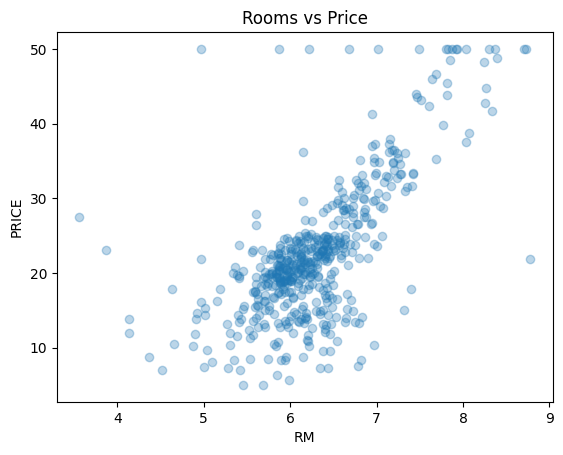

In [16]:
plt.scatter(df['RM'], df['PRICE'], alpha=0.3)
plt.xlabel('RM')
plt.ylabel('PRICE')
plt.title('Rooms vs Price')
plt.show()

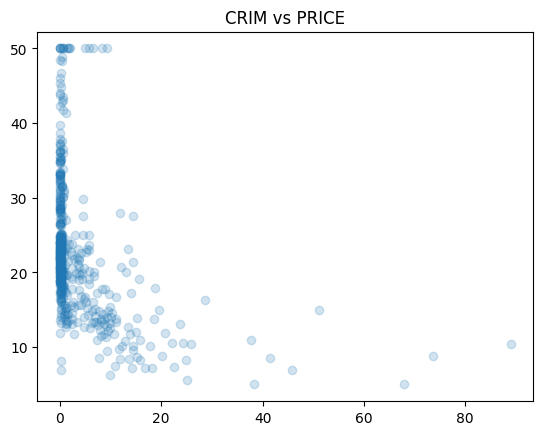

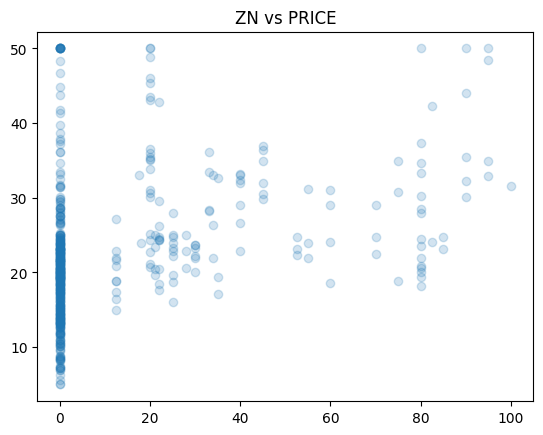

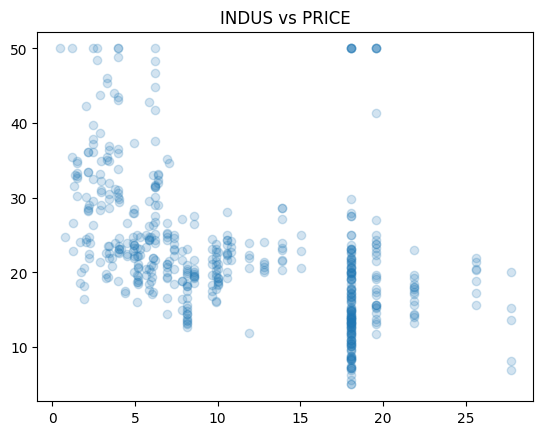

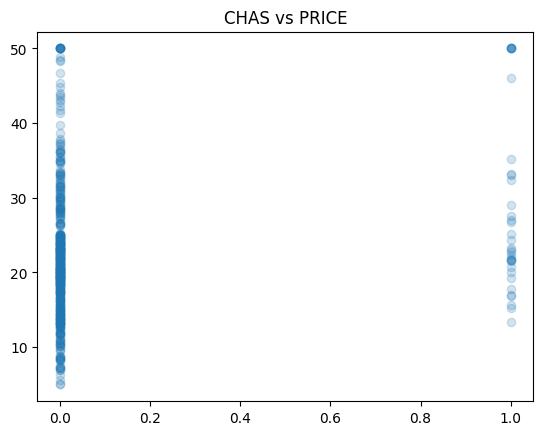

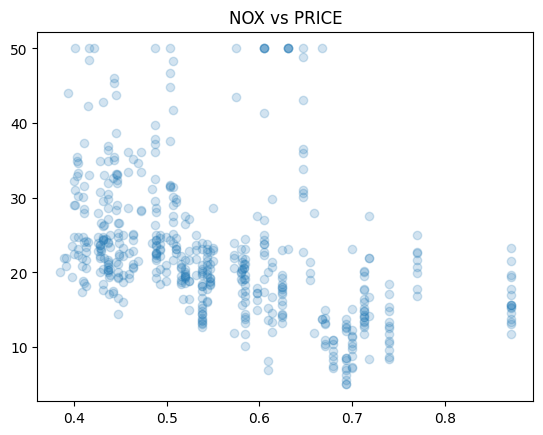

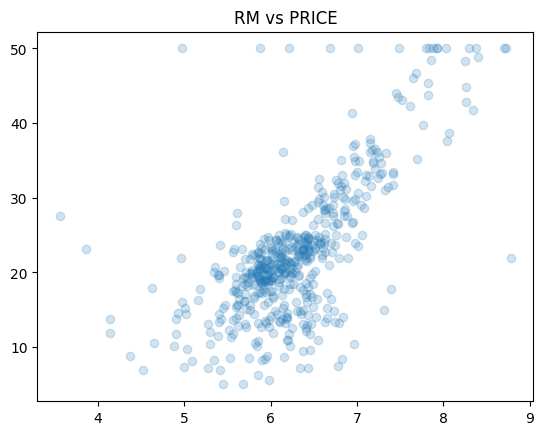

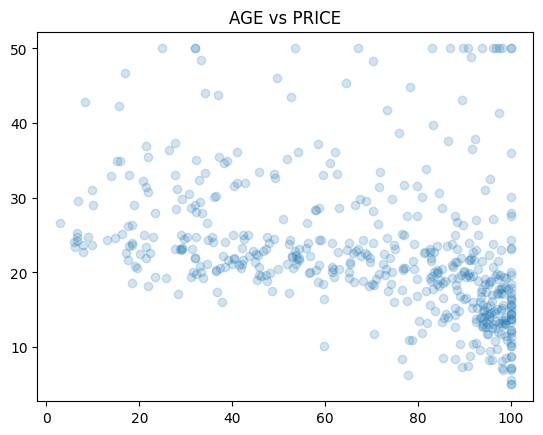

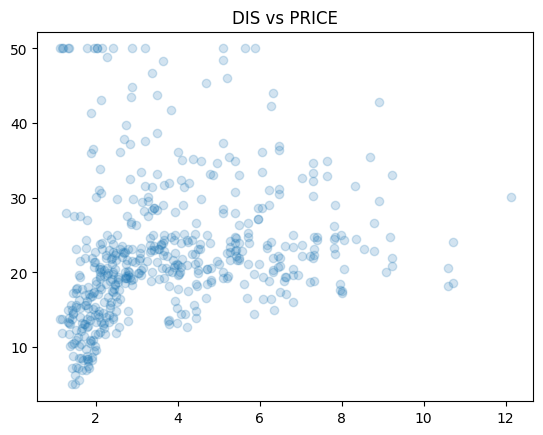

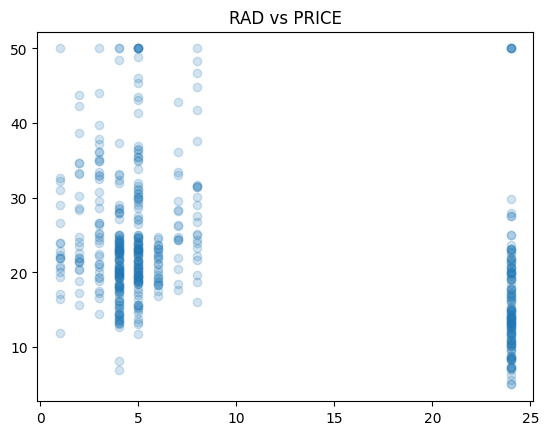

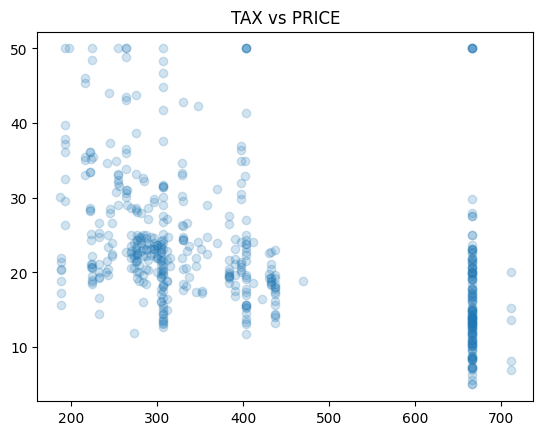

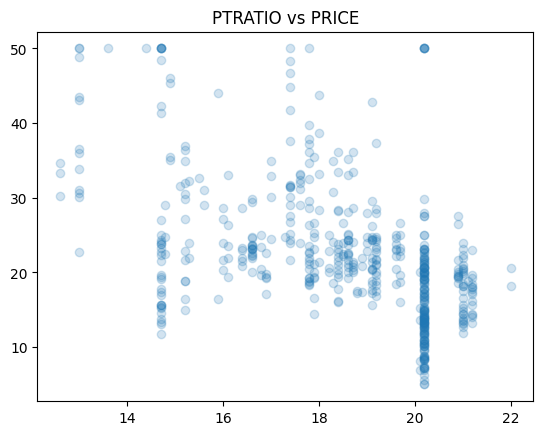

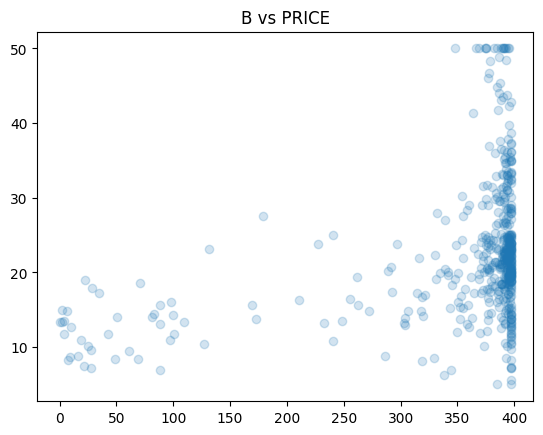

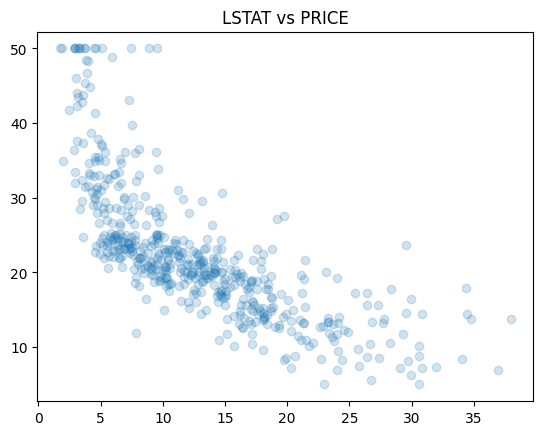

In [17]:
def scatter_all(data, target):
    for col in data.columns:
        if col != target:
            plt.figure()
            plt.scatter(data[col], data[target], alpha=0.2)
            plt.title(f'{col} vs {target}')
            plt.show()

scatter_all(df, 'PRICE')

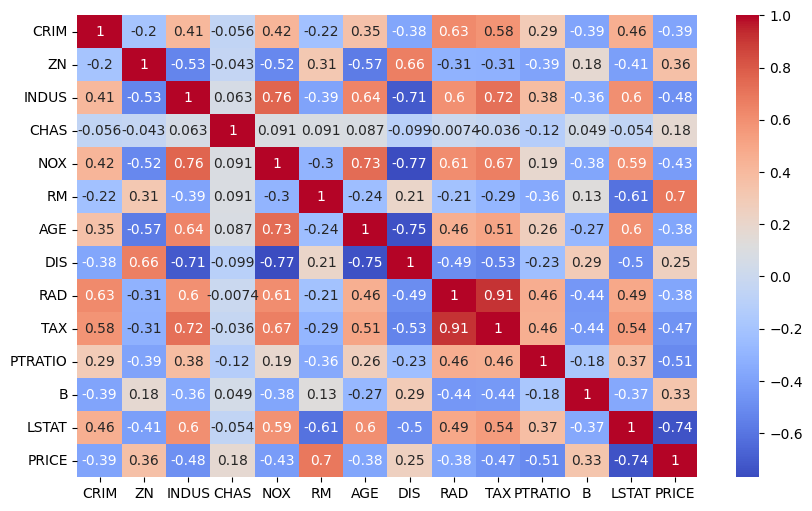

In [18]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

## 5. Model Training

In [19]:
X = df.drop('PRICE', axis=1)
y = df['PRICE']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

## 6. Model Evaluation

In [20]:
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print('RMSE:', rmse)
print('R2:', r2)

RMSE: 2.8109631609391226
R2: 0.8922527442109116


## 7. Parameter Tuning

In [21]:
model_tuned = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
model_tuned.fit(X_train, y_train)

y_pred_tuned = model_tuned.predict(X_test)
print('Tuned RMSE:', np.sqrt(mean_squared_error(y_test, y_pred_tuned)))
print('Tuned R2:', r2_score(y_test, y_pred_tuned))

Tuned RMSE: 2.9110413972043547
Tuned R2: 0.88444395405442


## 8. Prediction

In [22]:
new_data = X.iloc[0].values.reshape(1, -1)
prediction = model.predict(new_data)
print('Predicted Price:', prediction[0])

Predicted Price: 28.820999999999984


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
